<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 07

## Gradient Boosting

### Derivation and Analysis
Scenario A: Fitting a Constant Predictor from Scratch.
To find the optimal constant value $f$ that minimizes the binary cross-entropy (BCE) loss over the dataset,
we first define the loss function for a constant predictor:
$$L(f) = -\sum_{i=1}^{N} \left[ y_i \log(\sigma(f)) + (1-y_i) \log(1-\sigma(f)) \right].$$
To find the minimum, we take the derivative of $L(f)$ with respect to $f$ and set it to zero.
A standard property of the sigmoid function $\sigma(x)$ and BCE loss is that
the derivative of the loss with respect to the logit $f$ simplifies beautifully to the predicted probability minus the true label:
$$\frac{\partial L}{\partial f} = \sum_{i=1}^{N} (\sigma(f) - y_i) = 0.$$
Since $f$ is a constant for all $i$, $\sigma(f)$ is also a constant.
We can pull it out of the summation:
$$\sum_{i=1}^{N} \sigma(f) = \sum_{i=1}^{N} y_i .$$
Let $N$ be the total number of samples ($N = N_0 + N_1$).
The sum of the labels $y_i$ is simply the number of ones in the dataset, $N_1$:
$$N \cdot \sigma(f) = N_1,$$
$$\sigma(f) = \frac{N_1}{N}.$$
Now, we solve for $f$ using the inverse of the sigmoid function (the logit function):
$$f = \log\left(\frac{\sigma(f)}{1 - \sigma(f)}\right) = \log\left(\frac{N_1/N}{1 - N_1/N}\right) = \log\left(\frac{N_1/N}{N_0/N}\right).$$
Explicit solution:
$$f^* = \log\left(\frac{N_1}{N_0}\right).$$
Interpretation: The optimal constant $f^*$ represents the log-odds of the positive class in the dataset.
If there are equal numbers of zeros and ones ($N_0 = N_1$), the log-odds is $\log(1) = 0$,
meaning the baseline prediction before any features are considered is exactly $0.5$ in probability space.

Scenario B:
Fitting the m-th Predictor in the Forward Stagewise Procedure.
Now, we are looking for an additive shift $\gamma$ given existing predictions $f_i$.
The loss function is:
$$L(\gamma) = -\sum_{i=1}^{N} \left[ y_i \log(\sigma(f_i + \gamma)) + (1-y_i) \log(1-\sigma(f_i + \gamma)) \right].$$
Taking the derivative with respect to $\gamma$ and setting it to zero yields our implicit equation:
$$\frac{\partial L}{\partial \gamma} = \sum_{i=1}^{N} (\sigma(f_i + \gamma) - y_i) = 0.$$
Implicit equation:
$$\sum_{i=1}^{N} \sigma(f_i + \gamma) = N_1.$$
Discussion:
This implicit equation has no simple closed-form solution.
In Scenario A, because the argument to the sigmoid function was the same for all data points,
we could factor it out of the sum. In Scenario B, every data point has a different prior prediction $f_i$.
Because the sigmoid function is strictly non-linear,
$\sum \sigma(f_i + \gamma) \neq \sigma(\sum f_i + N\gamma)$.
The non-linearity prevents us from algebraically isolating $\gamma$.
To find the exact $\gamma$, we are forced to use numerical optimization methods
(like Newton-Raphson or Gradient Descent) rather than simply plugging numbers into a formula.

## Loss Landscape Exploration (Python)
Here is the Python code to generate the data, compute the losses, and visualize the landscapes.

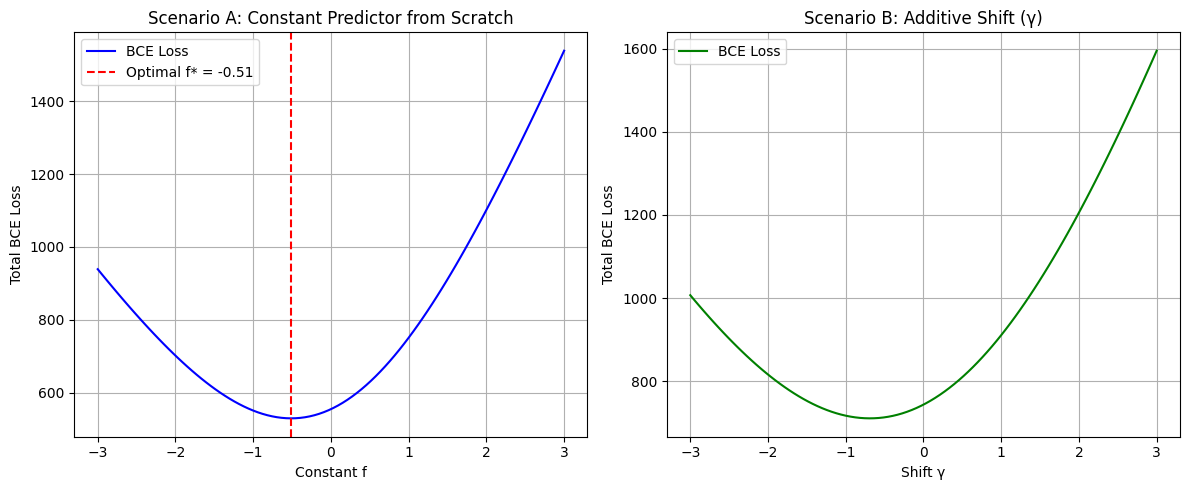

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Data and Parameters ---
N_0 = 500  # Number of zeros
N_1 = 300  # Number of ones
N = N_0 + N_1

# Create binary labels
y = np.array([0]*N_0 + [1]*N_1)

# Generate previous predictions f_i from a normal distribution
np.random.seed(42)
f_prev = np.random.normal(loc=0.0, scale=1.5, size=N)

# Define sigmoid and BCE functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def bce_loss_A(f):
    p = sigmoid(f)
    # Clip to avoid log(0)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_loss_B(gamma):
    p = sigmoid(f_prev + gamma)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

# --- 2. Compute Loss Landscapes ---
f_values = np.linspace(-3, 3, 100)
gamma_values = np.linspace(-3, 3, 100)

loss_A_vals = [bce_loss_A(f) for f in f_values]
loss_B_vals = [bce_loss_B(g) for g in gamma_values]

# --- 3. Plotting ---
plt.figure(figsize=(12, 5))

# Scenario A Plot
plt.subplot(1, 2, 1)
plt.plot(f_values, loss_A_vals, color='blue', label='BCE Loss')
plt.axvline(np.log(N_1/N_0), color='red', linestyle='--', label=f'Optimal f* = {np.log(N_1/N_0):.2f}')
plt.title('Scenario A: Constant Predictor from Scratch')
plt.xlabel('Constant f')
plt.ylabel('Total BCE Loss')
plt.legend()
plt.grid(True)

# Scenario B Plot
plt.subplot(1, 2, 2)
plt.plot(gamma_values, loss_B_vals, color='green', label='BCE Loss')
plt.title('Scenario B: Additive Shift (\u03B3)')
plt.xlabel('Shift \u03B3')
plt.ylabel('Total BCE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Discussion of the Loss Landscapes

### Is the loss landscape in Scenario A simpler or more complex than in Scenario B?
Visually and geometrically, they are practically identical in complexity. Both landscapes are smooth, continuous, bowl-shaped curves.

### Is it multimodal or unimodal?
Both loss landscapes are strictly unimodal. Binary cross-entropy loss with respect to logits is a strictly convex function. Because the sum of convex functions is also convex, the overall loss function in both scenarios retains a single, global minimum.

### Can the $\gamma$ minimizer be found numerically?

Yes, easily. Because the landscape is strictly convex and smooth (differentiable everywhere), numerical optimization algorithms like Gradient Descent or Newton's Method are guaranteed to converge rapidly to the global minimum without getting stuck in local minima.

### Where does the difficulty in Scenario B come from?
The difficulty in Scenario B does not come from a complex, non-convex, or multimodal loss landscape. The geometric shape is perfectly well-behaved. The difficulty is purely algebraic. The non-linearity of the sigmoid function applied over varying base values ($f_i$) creates a summation that cannot be analytically inverted to yield a neat $x = \dots$ formula.